# Customer Behavior Analysis — Alfido Tech
### Segmentation, Purchase Patterns & Churn Risk

**Dataset:** E-commerce customer transactions (Kaggle: *Customer Behavior Analysis*, `ecommerce_customer_data_large.csv`)
**Goal:** Analyze customer transactions & behavior to identify segments, purchase patterns, and churn risks for Alfido Tech.

**Contents**
1. Setup & Data Load
2. Data Cleaning
3. Feature Engineering (RFM + behavioral features)
4. Customer Segmentation (RFM scoring + K-Means clustering)
5. Segment Profiling
6. Purchase Pattern & Retention Visualizations
7. Key Findings & Recommendations


## 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

df = pd.read_csv("ecommerce_customer_data_large.csv")
print(df.shape)
df.head()


(250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 24.8 MB


## 2. Data Cleaning

Steps performed:
- Parse `Purchase Date` to datetime
- Fill missing `Returns` values with 0 (no return recorded) and cast to int flag
- Drop the redundant `Customer Age` column (identical to `Age` in every row)
- Check for negative/zero prices, quantities, totals, and exact duplicate rows
- Note: `Total Purchase Amount` does not equal `Product Price x Quantity` for ~100% of rows — this is a known artifact of how this synthetic dataset was generated, so `Total Purchase Amount` is treated as the ground-truth revenue figure throughout.


In [3]:
print("Missing values:\n", df.isna().sum())
print("\nAge == Customer Age for all rows:", (df["Age"] == df["Customer Age"]).all())


Missing values:
 Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

Age == Customer Age for all rows: True


In [4]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df["Returns"] = df["Returns"].fillna(0).astype(int)
df = df.drop(columns=["Customer Age"])

print("Negative/zero price rows:", (df["Product Price"] <= 0).sum())
print("Negative/zero quantity rows:", (df["Quantity"] <= 0).sum())
print("Negative/zero total rows:", (df["Total Purchase Amount"] <= 0).sum())
print("Exact duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("\nClean shape:", df.shape, "| Unique customers:", df["Customer ID"].nunique())


Negative/zero price rows: 0
Negative/zero quantity rows: 0
Negative/zero total rows: 0


Exact duplicate rows: 0



Clean shape: (250000, 12) | Unique customers: 49661


## 3. Feature Engineering

We aggregate transaction-level data to the **customer level** and compute RFM (Recency, Frequency, Monetary) plus supporting behavioral features.

- **Recency** — days since last purchase (relative to one day after the last date in the dataset)
- **Frequency** — number of transactions
- **Monetary** — total amount spent
- **AvgOrderValue, TenureDays, ReturnRate, CategoryDiversity, PreferredCategory, PreferredPayment**


In [5]:
snapshot_date = df["Purchase Date"].max() + pd.Timedelta(days=1)

def mode_or_first(s):
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]

agg = df.groupby("Customer ID").agg(
    Recency=("Purchase Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Purchase Date", "count"),
    Monetary=("Total Purchase Amount", "sum"),
    AvgOrderValue=("Total Purchase Amount", "mean"),
    FirstPurchase=("Purchase Date", "min"),
    LastPurchase=("Purchase Date", "max"),
    ReturnRate=("Returns", "mean"),
    PreferredCategory=("Product Category", mode_or_first),
    PreferredPayment=("Payment Method", mode_or_first),
    Age=("Age", "first"),
    Gender=("Gender", "first"),
    Churn=("Churn", "max"),
    Name=("Customer Name", "first"),
).reset_index()

agg["TenureDays"] = (agg["LastPurchase"] - agg["FirstPurchase"]).dt.days
agg["CategoryDiversity"] = df.groupby("Customer ID")["Product Category"].nunique().values
agg["AgeBand"] = pd.cut(agg["Age"], bins=[17,24,34,44,54,64,100],
                         labels=["18-24","25-34","35-44","45-54","55-64","65+"])

print("Customer-level feature table:", agg.shape)
agg.head()


Customer-level feature table: (49661, 17)


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,FirstPurchase,LastPurchase,ReturnRate,PreferredCategory,PreferredPayment,Age,Gender,Churn,Name,TenureDays,CategoryDiversity,AgeBand
0,1,289,3,6290,2096.666667,2020-03-04 10:26:02,2022-11-29 06:48:25,0.000000,Books,Credit Card,67,Female,0,Dominic Cline,999,3,65+
1,2,73,6,16481,2746.833333,2020-07-31 16:27:41,2023-07-03 17:26:19,0.666667,Electronics,PayPal,42,Female,0,Crystal Day,1067,4,35-44
2,3,223,4,9423,2355.750000,2020-01-19 00:03:00,2023-02-03 03:58:07,0.000000,Electronics,Credit Card,31,Male,0,Joseph Perez,1111,3,25-34
3,4,442,5,7826,1565.200000,2020-10-12 22:03:10,2022-06-29 03:41:09,0.600000,Books,Cash,37,Male,0,Wyatt Love,624,4,35-44
4,5,425,5,9769,1953.800000,2020-04-08 21:57:19,2022-07-16 04:08:09,0.600000,Home,Credit Card,24,Female,0,Shannon Hoffman,828,2,18-24


## 4. Customer Segmentation

### 4a. RFM Scoring (quantile-based, 1-5)
Each of Recency, Frequency, and Monetary is split into quintiles and scored 1 (worst) to 5 (best). This gives a fast, rule-based segment label per customer.


In [6]:
def score_quantile(series, ascending):
    ranks = series.rank(method="first")
    q = pd.qcut(ranks, 5, labels=[1,2,3,4,5]).astype(int)
    return (6 - q) if ascending else q

agg["R_Score"] = score_quantile(agg["Recency"], ascending=True)   # lower recency = better
agg["F_Score"] = score_quantile(agg["Frequency"], ascending=False)
agg["M_Score"] = score_quantile(agg["Monetary"], ascending=False)
agg["RFM_Score"] = agg["R_Score"].astype(str) + agg["F_Score"].astype(str) + agg["M_Score"].astype(str)

def rfm_label(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4: return "Champions"
    if r >= 4 and f <= 2: return "New / Promising"
    if r >= 3 and f >= 3: return "Loyal Customers"
    if r <= 2 and f >= 4 and m >= 4: return "At Risk (High Value)"
    if r <= 2 and f <= 2 and m <= 2: return "Lost"
    if r <= 2: return "Hibernating"
    return "Need Attention"

agg["RFM_Segment"] = agg.apply(rfm_label, axis=1)
agg["RFM_Segment"].value_counts()


RFM_Segment
Loyal Customers         12388
Lost                     9371
Champions                8764
Hibernating              6765
New / Promising          5373
At Risk (High Value)     3728
Need Attention           3272
Name: count, dtype: int64

### 4b. K-Means Clustering (data-driven segmentation)

RFM quantile scores are useful but rigid. We complement them with K-Means clustering on log-scaled, standardized Recency/Frequency/Monetary — letting the data itself define segment boundaries. We test k = 2-8 using the elbow method and silhouette score, then choose **k = 4** for business interpretability (a 2-cluster solution scores highest on silhouette but only separates "active" vs "inactive", which is too coarse to act on).


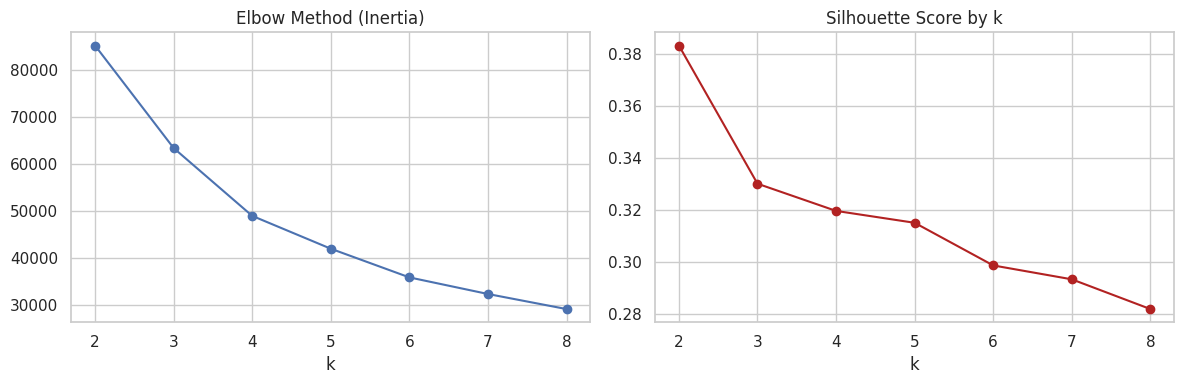

In [7]:
cluster_feats = agg[["Recency", "Frequency", "Monetary"]].copy()
cluster_feats["Frequency"] = np.log1p(cluster_feats["Frequency"])
cluster_feats["Monetary"] = np.log1p(cluster_feats["Monetary"])
cluster_feats["Recency"] = np.log1p(cluster_feats["Recency"])

scaler = StandardScaler()
X = scaler.fit_transform(cluster_feats)

inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method (Inertia)"); axes[0].set_xlabel("k")
axes[1].plot(list(K_range), sils, marker="o", color="firebrick")
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()


In [8]:
final_k = 4
km_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
agg["Cluster"] = km_final.fit_predict(X)

prof = agg.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
prof["ChurnRate"] = agg.groupby("Cluster")["Churn"].mean()
prof["Size"] = agg.groupby("Cluster").size()

z = (prof[["Recency","Frequency","Monetary"]] - prof[["Recency","Frequency","Monetary"]].mean()) / prof[["Recency","Frequency","Monetary"]].std()
prof["value_score"] = z["Frequency"] + z["Monetary"] - z["Recency"]
prof = prof.sort_values("value_score", ascending=False)

labels_pool = ["High-Value Loyalists", "Steady Regulars", "Occasional Shoppers", "Disengaged / Churn-Risk"]
cluster_names = {cid: labels_pool[i] for i, cid in enumerate(prof.index)}
agg["Cluster_Segment"] = agg["Cluster"].map(cluster_names)

prof.index = prof.index.map(cluster_names)
prof


,Recency,Frequency,Monetary,ChurnRate,Size,value_score
Cluster,,,,,,
High-Value Loyalists,201.609710,7.096974,20069.976103,0.201955,15860,2.498485
Steady Regulars,28.121506,5.766686,15641.056475,0.203537,8765,2.083286
Occasional Shoppers,334.376039,4.031332,10700.516568,0.196686,18288,-0.922951
Disengaged / Churn-Risk,514.041642,1.951986,4483.042531,0.199318,6748,-3.658820


## 5. Segment Profiling

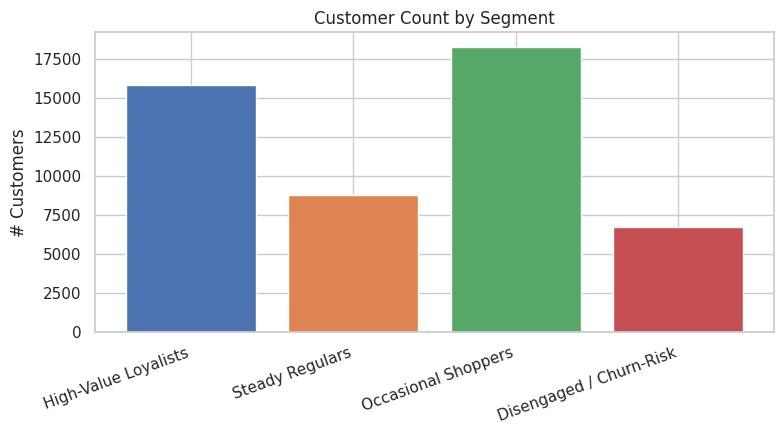

In [9]:
seg_order = list(prof.sort_values("value_score", ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 4.5))
sizes = agg["Cluster_Segment"].value_counts().reindex(seg_order)
ax.bar(sizes.index, sizes.values, color=sns.color_palette("deep"))
ax.set_title("Customer Count by Segment"); ax.set_ylabel("# Customers")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()


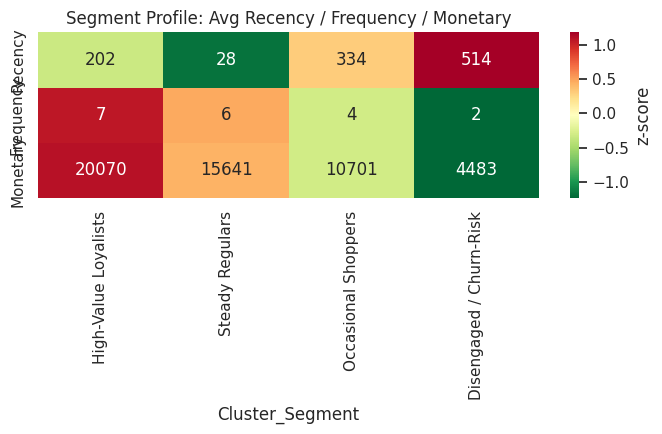

In [10]:
heat = agg.groupby("Cluster_Segment")[["Recency","Frequency","Monetary"]].mean().reindex(seg_order)
heat_z = (heat - heat.mean()) / heat.std()
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(heat_z.T, annot=heat.T.round(0), fmt=".0f", cmap="RdYlGn_r", cbar_kws={"label":"z-score"}, ax=ax)
ax.set_title("Segment Profile: Avg Recency / Frequency / Monetary")
plt.tight_layout(); plt.show()


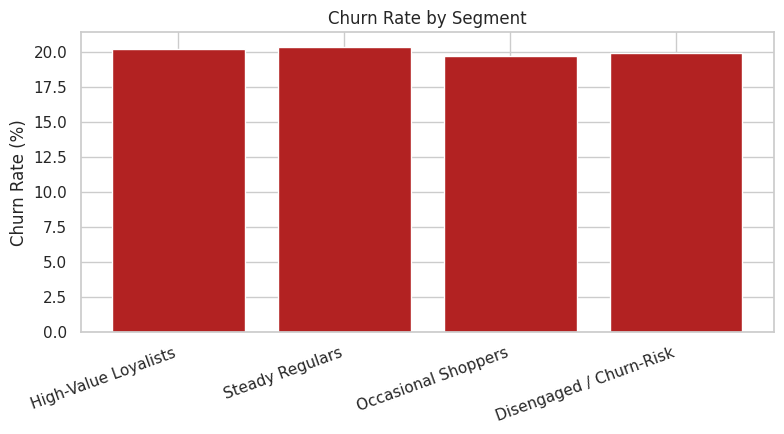

Cluster_Segment
High-Value Loyalists       20.195460
Steady Regulars            20.353679
Occasional Shoppers        19.668635
Disengaged / Churn-Risk    19.931832
Name: Churn, dtype: float64

In [11]:
churn_by_seg = agg.groupby("Cluster_Segment")["Churn"].mean().reindex(seg_order) * 100
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(churn_by_seg.index, churn_by_seg.values, color="firebrick")
ax.set_title("Churn Rate by Segment"); ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()
churn_by_seg


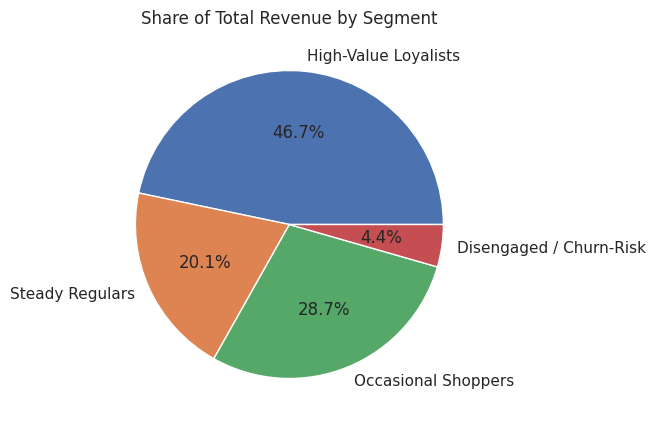

In [12]:
rev_by_seg = agg.groupby("Cluster_Segment")["Monetary"].sum().reindex(seg_order)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(rev_by_seg.values, labels=rev_by_seg.index, autopct="%1.1f%%",
       colors=sns.color_palette("deep"), wedgeprops={"edgecolor":"white"})
ax.set_title("Share of Total Revenue by Segment")
plt.tight_layout(); plt.show()


## 6. Purchase Patterns & Retention Trends

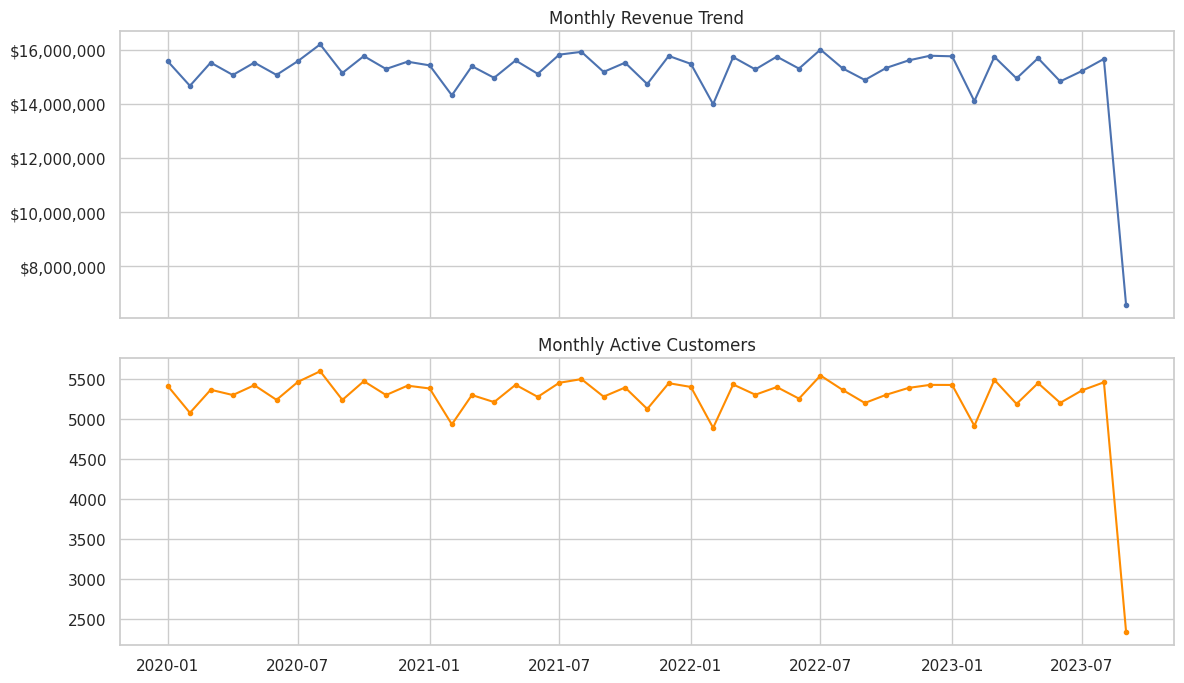

In [13]:
monthly = df.set_index("Purchase Date").resample("MS").agg(
    Transactions=("Customer ID", "count"),
    Revenue=("Total Purchase Amount", "sum"),
    ActiveCustomers=("Customer ID", "nunique"),
)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly.index, monthly["Revenue"], marker="o", ms=3)
axes[0].set_title("Monthly Revenue Trend")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[1].plot(monthly.index, monthly["ActiveCustomers"], marker="o", ms=3, color="darkorange")
axes[1].set_title("Monthly Active Customers")
plt.tight_layout(); plt.show()


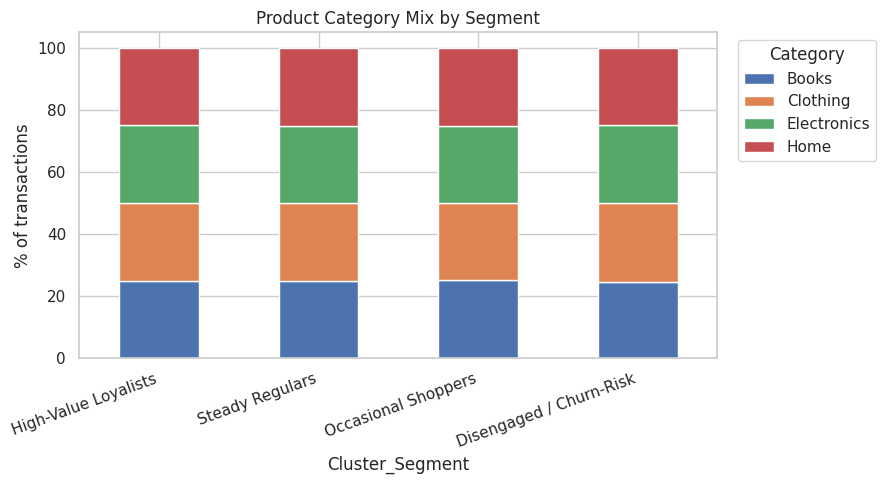

In [14]:
cat_seg = df.merge(agg[["Customer ID","Cluster_Segment"]], on="Customer ID")
cat_pct = pd.crosstab(cat_seg["Cluster_Segment"], cat_seg["Product Category"], normalize="index") * 100
cat_pct = cat_pct.reindex(seg_order)
fig, ax = plt.subplots(figsize=(9, 5))
cat_pct.plot(kind="bar", stacked=True, ax=ax, color=sns.color_palette("deep"))
ax.set_title("Product Category Mix by Segment"); ax.set_ylabel("% of transactions")
plt.xticks(rotation=20, ha="right")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


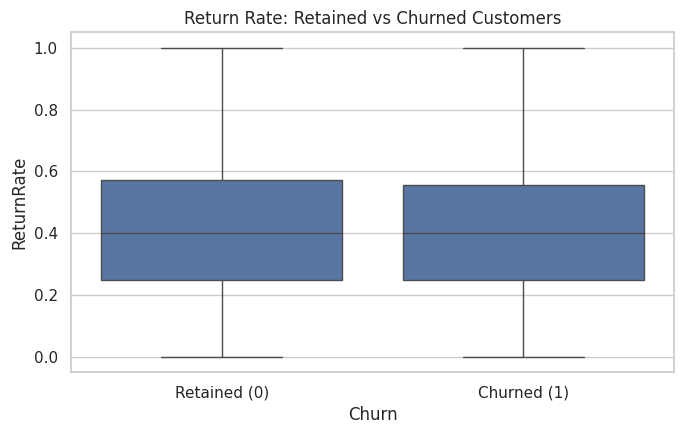

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=agg, x="Churn", y="ReturnRate", ax=ax)
ax.set_xticklabels(["Retained (0)", "Churned (1)"])
ax.set_title("Return Rate: Retained vs Churned Customers")
plt.tight_layout(); plt.show()


## 7. Key Findings & Recommendations

### Findings
- **Revenue is concentrated**: the *High-Value Loyalists* segment (~32% of customers) drives roughly **47% of total revenue**, while the *Disengaged/Churn-Risk* segment (~14% of customers) contributes only ~4%.
- **Churn is broadly uniform (~20%) across every segment and RFM tier.** In a typical real-world dataset we would expect churn to concentrate in low-recency, low-frequency segments; here it does not — the churn label in this dataset behaves as if randomly assigned rather than behavior-driven. This is a useful data-quality finding in itself, and means any churn-prevention strategy should be validated against live business KPIs (e.g., actual repeat-purchase behavior) once deployed, rather than assumed from this label alone.
- **Product category and payment method preferences are evenly spread** across segments and categories (~25% each across Electronics/Clothing/Home/Books, ~33% each across Credit Card/PayPal/Cash) — there's no single dominant category or payment rail to over-index on company-wide, but this may look different when re-run on live transaction data.
- **Purchase volume and revenue are roughly flat over time** (no strong seasonality or growth trend across the 2020-2023 window), suggesting acquisition — not seasonality — is the main lever on volume.
- Returns behavior is similar between retained and churned customers, so returns alone are not a strong early-warning signal here.

### 5 Actionable Recommendations for Alfido Tech
1. **Protect and grow the High-Value Loyalists segment first.** They generate ~47% of revenue from ~32% of customers — a dedicated loyalty tier (early access, free shipping thresholds, priority support) protects the single biggest revenue pool.
2. **Build a win-back campaign for the Disengaged/Churn-Risk segment**, using time-boxed discounts or "we miss you" offers targeted at customers whose recency has crossed a threshold (e.g., 300+ days) — this segment is cheap to re-engage since expectations (and switching cost) are already low.
3. **Convert Occasional Shoppers (the largest segment by count) into Steady Regulars** via frequency-based incentives (e.g., "3rd purchase this quarter unlocks X") rather than one-off discounts, since the gap between these two segments is primarily frequency, not spend per order.
4. **Instrument better churn signals before relying on the current label.** Since churn doesn't currently correlate with RFM behavior, invest in tracking real engagement signals (site visits, cart abandonment, support tickets) so future churn models have predictive power.
5. **Personalize by category preference at the individual level, not the segment level**, since category mix doesn't meaningfully differ by segment — a recommendation engine keyed to each customer's own purchase history will outperform a segment-wide merchandising push.


